# PICSHEP TUTORIAL
$\nu$ - DM interactions in AGN

#### Loading the PICSHEP package

In [1]:
import sys
src_path = "../../src/"
sys.path.append(src_path)
from PICSHEP import CascadeEquationSolver, Model 


**************************************************************************
Particle Interactions Cascade equation Solver for High Energy Physics

Author: ShivaSankar K.A
        シヴァサンカール 
        旭輝

Affiliation: PhD, 北海道大学宇宙理学専攻、大学院理学院, 北海道大学
Department of CosmoSciences, Graduate School of Science, Hokkaido University

Email: shivasankar.ka@gmail.com
*************************************************************************



### Initializing CES and model
The required functions are defined in the PICSHEP package in the ces and model classs. Therefore, We initialize them first. 

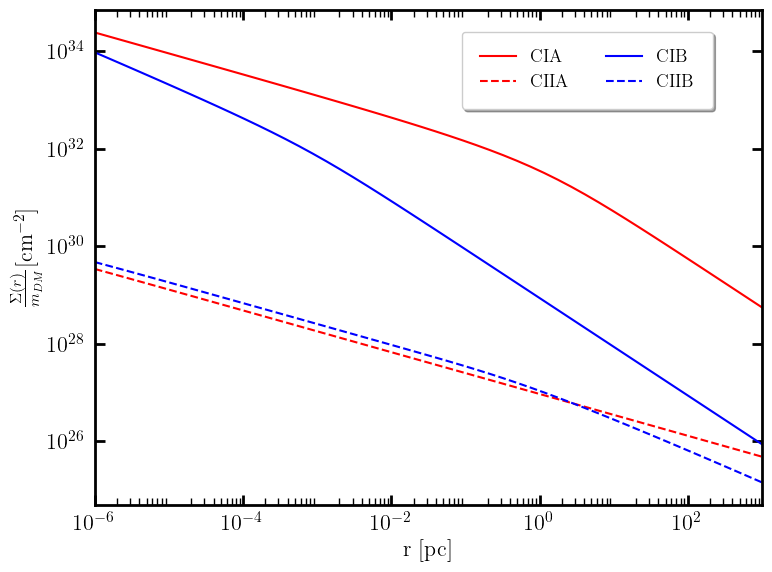

In [2]:
ces = CascadeEquationSolver()
model = Model(path="./")
model.set_model_name(model_name="AGN",model_type="CIA")

### Intializing the input functions
The required inputs such as cross section, differential cross section, unattenuated flux and effective area of interaction can be provided using the inbuilt functions as shown below in this example. You can either provide the functional form or the numerical data which will be interpolated. 

In [3]:
F0 = 13.22
F1 = 1.498
F2 = -0.00167
F3 = 4.119

xchi  = 2.0
xH    = -1
xv    = -1/2*(xH) - 1.0
QX    = xchi**2 * xv**2

#U(1)_X cross section
def diff_cross_section(E, x, a, b, dm_mass):
    return QX * a * (1 + E**2/x**2) * 1/((1+2*b*(x-E))**2)

def cross_section(E, a, b, m_chi):
    return QX * (1/(4*b**3*E**2))*a*(2*b*E**2*((4*b*E*(2*b*E+1)+1)/(4*b*E**2+2*E+m_chi))+1/(2*E+m_chi)-(2*b*E+1)*np.log(4*b*E**2+2*E+m_chi)+(2*b*E+1)*np.log(2*E+m_chi))

def flux(E):
    return 4.9032578920279493e-11 * (E)**-3.196
    
# model.set_diff_cross_section(diff_cross_section="lambda E,x,a,b,dm_mass: "+str(QX)+"* a*(1 + E**2/x**2)* 1/((1+2*b*(x-E))**2)")
# model.set_cross_section(cross_section="lambda E,a,b,m_chi: "+str(QX)+"* (1/(4*b**3*E**2))*a*(2*b*E**2*((4*b*E*(2*b*E+1)+1)/(4*b*E**2+2*E+m_chi))+1/(2*E+m_chi)-(2*b*E+1)*np.log(4*b*E**2+2*E+m_chi)+(2*b*E+1)*np.log(2*E+m_chi))")
# model.set_flux_func(flux="4.9032578920279493e-11 * (E)**-3.196")

model.set_diff_cross_section_function(diff_cross_section=diff_cross_section)
model.set_cross_section_function(cross_section=cross_section)
model.set_flux_func(flux=flux)
model.set_eff_area_data(effective_area="input/eff_area.csv")
model.set_np_parameterization(m="np.sqrt(dm_mass/(B))",
                              g="(mzp**2) * np.sqrt(A/(Sigma*10**3)) * np.sqrt(8*np.pi)"
                              )
model.set_energy_range(e_min=1.5, e_max=15) #TeV

Parameterization of new physics parameters initialized:
 m=np.sqrt(dm_mass/(B))
 g=(mzp**2) * np.sqrt(A/(Sigma*10**3)) * np.sqrt(8*np.pi)



We set the model with the functions defined above

In [4]:
ces.set_model(model=model)

CES.events calculates the no of events for the selected parameter range in the energy range provided. The input required are
1. $E_{\text{min}}$: The minimum energy of inteaction above which we need to calculate the events
2. $E_{\text{max}}$: The maximum energy which should theoretically be $\infty$, but for numerical purposes, it is the maximum energy where the flux function is well defined. 
3. $t_{\text{obs}}$: The observation time of the experiment in consideration (ICECUBE in this case)
4. $A$ and $B$ are the two parameters used to parameterize the cross section and differential cross section. Provide a range in which you want to probe these parameters. 

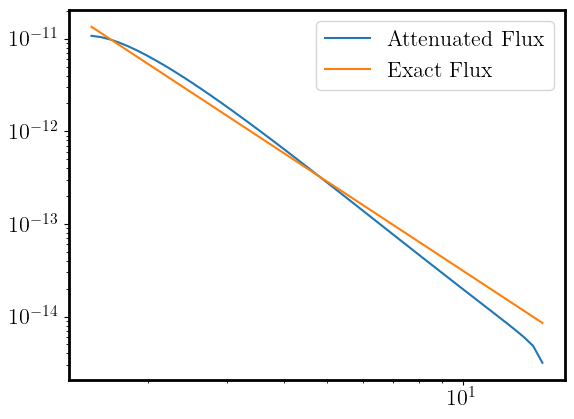

In [5]:
import numpy as np
import matplotlib.pyplot as plt

energy_arr = np.logspace(np.log10(model.e_min), np.log10(model.e_max), 50, dtype=np.float64)
phi_sol = np.zeros(len(energy_arr))
for i in range(len(energy_arr)):
    phi_sol[i] = ces.attenuated_flux(energy = energy_arr[i], num = 50, a_mat = 10.0, b_mat = 10.0)
phi_exact = model.flux(energy_arr)
plt.plot(energy_arr, phi_sol, label='Attenuated Flux')
plt.plot(energy_arr, phi_exact, label='Exact Flux')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

In [6]:
ces.events(e_min=1.5, e_max=15, t_obs= 3186.105475562*24*3600, a_range=[-3,3], b_range=[-3,3], n_val=20, n_eig=20)

TypeError: Model.set_cross_section_function.<locals>.<lambda>() takes 1 positional argument but 4 were given

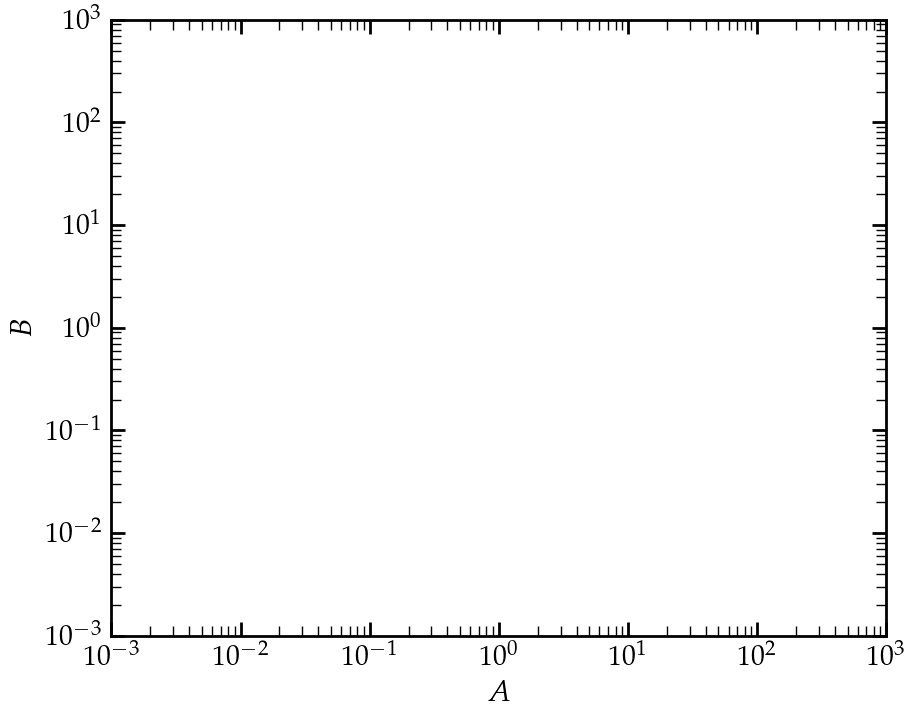

In [7]:
ces.plot(xlim=[10**-3,10**3],
          ylim=[10**-3,10**3],
            title="AvsB",
            do_plot = False,
              plot_save=True,
              event_threshold=0.1*32)

In [8]:
CES.plotmvsg(title="AvsB", plotsave=False)

NameError: name 'CES' is not defined

In [8]:
CES.eigcalc(Energy=15,num=15,a=0.00,b=0.1)

8.544704970122675e-15

[-1.86264515e-09  4.22941986e-27 -1.68898254e-10 -1.27043397e-25
 -3.46093216e-11 -1.57293094e-11  1.88600106e-12  3.82534471e-12
  1.70585165e-12  1.74964260e-12  1.53618377e-12  1.25234969e-12
  1.09756647e-12  1.01220812e-12  8.93669116e-13  7.75839904e-13
  6.87559032e-13  6.24910106e-13  5.54884024e-13  4.93798361e-13
  4.44023498e-13  4.02306345e-13  3.65093708e-13  3.31234561e-13
  3.02709827e-13  2.76223887e-13  2.52954224e-13  2.32512234e-13
  2.13434444e-13  1.97349750e-13  1.81678174e-13  1.68825371e-13
  1.56036792e-13  1.45486245e-13  1.34935698e-13  1.26193196e-13
  1.17534040e-13  1.10097465e-13  1.02988384e-13  9.65377726e-14
  9.07017350e-14  8.50083228e-14  8.02173885e-14  7.54264542e-14
  7.11855860e-14  6.72525845e-14  6.33377380e-14  6.01090064e-14
  5.68802749e-14  5.38160669e-14  5.11654830e-14  4.85148992e-14
  4.60596039e-14  4.38836278e-14  4.17076517e-14  3.96875777e-14
  3.79012169e-14  3.61148562e-14  3.44065151e-14  3.29399999e-14
  3.14734848e-14  3.00069

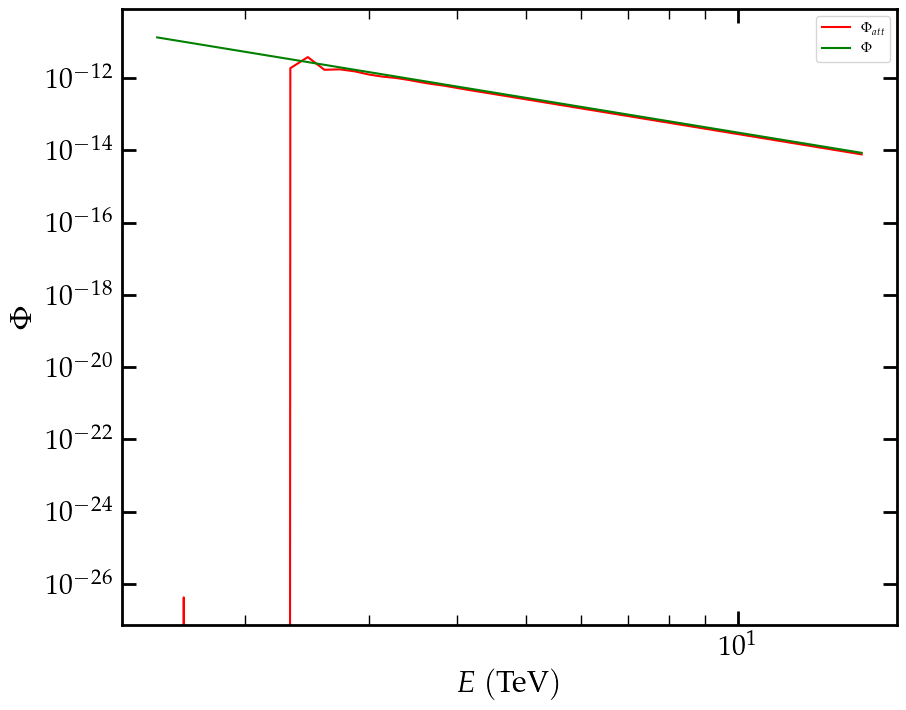

In [9]:
CES.attenuated_flux(Emin = 1.5, Emax = 15, N_eig = 50,Aval = 10**1,Bval=10**2)

In [10]:
CES.total_events(Emin=1.5,Emax=15,Aval=0.0,Bval=10**-1,t_obs= 3186.105475562*24*3600,N_eig=50)

No of events: 30.84128967871357
